In [1]:

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
import pandas as pd



In [2]:
#parse the foodweb data

file_path = "Foodweb/data.xls"


#read the data
data = pd.read_excel(file_path)
#There are 2 different data sets in the file (ID,TSN,Name,Phylum) then a gap and it repeats again for the second data set (ID,TSN,Name,Phylum)
#separate the data into 2 dataframes
intertidal = data.iloc[:, :4]
#keep data1 until the first nan value row
intertidal = intertidal[intertidal.notna().all(axis=1)]
nearshore = data.iloc[:, 5:]






print(nearshore)


    Sanak Nearshore Marine Food Web Unnamed: 6         Unnamed: 7  \
0                                ID        TSN               Name   
1                                 1      10031        Gymnodinium   
2                                 2      10212         Peridinium   
3                                 3      10340    Protoperidinium   
4                                 4      10359          Gonyaulax   
..                              ...        ...                ...   
509                             509     179725       Corvus corax   
510                             510     554029  Aethia psittacula   
511                             511     554127   Anthus rubescens   
512                             512     686683    Bubo scandiacus   
513                             513      78536  Cinclus mexicanus   

          Unnamed: 8  
0             Phylum  
1    Pyrrophycophyta  
2    Pyrrophycophyta  
3    Pyrrophycophyta  
4    Pyrrophycophyta  
..               ...  
509       

In [3]:
# This cell was redundant - removed

In [4]:
#check the Trophic Links sheet

trophic_links = pd.read_excel(file_path, sheet_name="Trophic Links")

print(trophic_links)




     Sanak Intertidal Food Web Unnamed: 1  Unnamed: 2  \
0                     Consumer   Resource         NaN   
1                            9          9         NaN   
2                            9         64         NaN   
3                            9         87         NaN   
4                            9        150         NaN   
...                        ...        ...         ...   
6770                       NaN        NaN         NaN   
6771                       NaN        NaN         NaN   
6772                       NaN        NaN         NaN   
6773                       NaN        NaN         NaN   
6774                       NaN        NaN         NaN   

     Sanak Nearshore Marine Food Web Unnamed: 4  
0                           Consumer   Resource  
1                                  1        200  
2                                  1        241  
3                                  1        244  
4                                  2          1  
...            

In [5]:
#separate the data into 2 dataframes (ID,ID) gap (ID,ID)
intertidal_links = trophic_links.iloc[:, :2]
#also remove the rows with nan value
intertidal_links = intertidal_links[intertidal_links.notna().all(axis=1)]
nearshore_links = trophic_links.iloc[:, 3:5]  # Fix: Only take 2 columns, not all remaining
#also remove the rows with nan value for nearshore links
nearshore_links = nearshore_links[nearshore_links.notna().all(axis=1)]

#print the dataframes
print(intertidal_links)


     Sanak Intertidal Food Web Unnamed: 1
0                     Consumer   Resource
1                            9          9
2                            9         64
3                            9         87
4                            9        150
...                        ...        ...
1800                       234        226
1801                       234        228
1802                       234        229
1803                       234        230
1804                       235         73

[1805 rows x 2 columns]


In [6]:
print(nearshore_links)

     Sanak Nearshore Marine Food Web Unnamed: 4
0                           Consumer   Resource
1                                  1        200
2                                  1        241
3                                  1        244
4                                  2          1
...                              ...        ...
6770                             512        504
6771                             512        506
6772                             512        507
6773                             512        508
6774                             513        217

[6775 rows x 2 columns]


In [7]:
#the first row is the title row, so we need to use it as the header but not as a row

intertidal.columns = intertidal.iloc[0]


intertidal = intertidal.iloc[1:]

intertidal.head()




,ID,TSN,Name,Phylum
1,1,10824,Pilayella littoralis,Phaeophyta
2,2,11217,Laminaria,Phaeophyta
3,3,11246,Agarum,Phaeophyta
4,4,11250,Costaria costata,Phaeophyta
5,5,11255,Saccharina sessile,Phaeophyta


In [8]:
#same for nearshore
nearshore.columns=nearshore.iloc[0]
nearshore=nearshore.iloc[1:]

nearshore.head()

,ID,TSN,Name,Phylum
1,1,10031,Gymnodinium,Pyrrophycophyta
2,2,10212,Peridinium,Pyrrophycophyta
3,3,10340,Protoperidinium,Pyrrophycophyta
4,4,10359,Gonyaulax,Pyrrophycophyta
5,5,10397,Ceratium,Pyrrophycophyta


In [9]:
#same for intertidal links
intertidal_links.columns = intertidal_links.iloc[0]
intertidal_links = intertidal_links.iloc[1:]


intertidal_links.head()


,Consumer,Resource
1,9,9
2,9,64
3,9,87
4,9,150
5,9,168


In [10]:
#same for nearshore links
nearshore_links.columns = nearshore_links.iloc[0]
nearshore_links = nearshore_links.iloc[1:]
nearshore_links.head()


,Consumer,Resource
1,1,200
2,1,241
3,1,244
4,2,1
5,2,2


In [11]:
#now we have the dataframe of the nodes and the links
#first lets check if all the nodes of the smallest network are present in the other network
#lets check the intertidal network
#get the TSNS of the intertidal network(the second column)
intertidal_TSNS = intertidal.iloc[:, 1]
#get the TSNS of the nearshore network(the second column)
nearshore_TSNS = nearshore.iloc[:, 1]
#print the length of the nodes
print(len(intertidal_TSNS))
print(len(nearshore_TSNS))



233
513


In [12]:
#since intetidal has less we will check if all the nodes of the intertidal network are present in the nearshore network
#summarize the results
print(intertidal_TSNS.isin(nearshore_TSNS).value_counts())
#almost all of them are present but not all so we cannot disregard it 
#however we can merge the two datasets and add two columns to indicate if the species is intertidal and/or nearshore



TSN
True     226
False      7
Name: count, dtype: int64


In [13]:
#first lets merge the two datasets but without the ID column
#select only TSN, Name, and Phylum columns for merging
intertidal_clean = intertidal[["TSN", "Name", "Phylum"]].copy()
nearshore_clean = nearshore[["TSN", "Name", "Phylum"]].copy()

merged_data = pd.merge(intertidal_clean, nearshore_clean, on="TSN", how="outer", suffixes=('_intertidal', '_nearshore'))

#combine Name and Phylum columns - use intertidal values first, then nearshore if intertidal is NaN
merged_data["Name"] = merged_data["Name_intertidal"].fillna(merged_data["Name_nearshore"])
merged_data["Phylum"] = merged_data["Phylum_intertidal"].fillna(merged_data["Phylum_nearshore"])

#drop the separate columns
merged_data = merged_data.drop(["Name_intertidal", "Name_nearshore", "Phylum_intertidal", "Phylum_nearshore"], axis=1)

#add the two columns
merged_data["Intertidal"] = merged_data["TSN"].isin(intertidal_TSNS)
merged_data["Nearshore"] = merged_data["TSN"].isin(nearshore_TSNS)

print(merged_data)

0       TSN                      Name           Phylum  Intertidal  Nearshore
0       601              Cyanophycota     Cyanophycota        True       True
1      1447               Chrysophyta      Chrysophyta        True       True
2      2135          Prymnesiophyceae       Haptophyta        True       True
3      2286           Bacillariophyta  Bacillariophyta        True      False
4      2546             Coscinodiscus  Bacillariophyta       False       True
..      ...                       ...              ...         ...        ...
515  san419            Phyllobothrium  Platyhelminthes       False       True
516  san420     Nybelinia surmenicola  Platyhelminthes       False       True
517  san455             Thalassomyces         Protozoa       False       True
518  san788  Hysterothylacium aduncum           Nemata       False       True
519  san934           Pseudoterranova           Nemata       False       True

[520 rows x 5 columns]


In [14]:
#now we also need to merge the links but before we do that we need to change the ID's to TSN's
#starting from intertidal dataset we create a dictionary of the ID and TSN
intertidal_ID_TSN = dict(zip(intertidal["ID"], intertidal["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the intertidal_links dataframe
intertidal_links_TSN = intertidal_links.copy()
intertidal_links_TSN["Consumer"] = intertidal_links_TSN["Consumer"].map(intertidal_ID_TSN)
intertidal_links_TSN["Resource"] = intertidal_links_TSN["Resource"].map(intertidal_ID_TSN)

# Remove rows where mapping failed (NaN values)
intertidal_links_TSN = intertidal_links_TSN.dropna()
print(intertidal_links_TSN)

#now we do the same for the nearshore dataset
nearshore_ID_TSN = dict(zip(nearshore["ID"], nearshore["TSN"]))
#now we can use this dictionary to map the ID's to TSN's in the nearshore_links dataframe
nearshore_links_TSN = nearshore_links.copy()
nearshore_links_TSN["Consumer"] = nearshore_links_TSN["Consumer"].map(nearshore_ID_TSN)
nearshore_links_TSN["Resource"] = nearshore_links_TSN["Resource"].map(nearshore_ID_TSN)

# Remove rows where mapping failed (NaN values)
nearshore_links_TSN = nearshore_links_TSN.dropna()
print(nearshore_links_TSN)





0    Consumer Resource
1      113265   113265
2      113265     2286
3      113265      601
4      113265    93295
6        1447   202421
...       ...      ...
1800   686683   177935
1801   686683   179492
1802   686683   179526
1803   686683   179531
1804    78536    48739

[1689 rows x 2 columns]
0    Consumer Resource
1       10031     2135
2       10031   590745
3       10031      601
4       10212    10031
5       10212    10212
...       ...      ...
6770   686683   177935
6771   686683   179492
6772   686683   179526
6773   686683   179531
6774    78536    48739

[6774 rows x 2 columns]


In [15]:
# We want to create a merged links dataframe with one row per unique (Consumer, Resource) pair,
# and two columns: 'Intertidal' and 'Nearshore', indicating presence (True/False) in each network.

# First, get sets of (Consumer, Resource) tuples for each network
intertidal_links_set = set(tuple(x) for x in intertidal_links_TSN[["Consumer", "Resource"]].values)
nearshore_links_set = set(tuple(x) for x in nearshore_links_TSN[["Consumer", "Resource"]].values)

# Get all unique links
all_links = intertidal_links_set.union(nearshore_links_set)

# Build the merged DataFrame
merged_links = pd.DataFrame(list(all_links), columns=["Consumer", "Resource"])
merged_links["Intertidal"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in intertidal_links_set, axis=1)
merged_links["Nearshore"] = merged_links.apply(lambda row: (row["Consumer"], row["Resource"]) in nearshore_links_set, axis=1)

print(merged_links)



     Consumer Resource  Intertidal  Nearshore
0      157215   157215       False       True
1       73293    89609        True       True
2      157152   202421        True       True
3      165427    97106       False       True
4      172932    97774       False       True
...       ...      ...         ...        ...
6912   175062     6501        True       True
6913   177013   667083       False       True
6914   164722    82415       False       True
6915    85524   158650       False       True
6916   180480   167123       False       True

[6917 rows x 4 columns]


In [16]:
#now create an nx graph from the merged links dataframe but also use the metadata from the merged_data dataframe

# Create a directed graph
G = nx.DiGraph()

# Add nodes for all unique TSNs in merged_links, with metadata from merged_data if available
all_TSNs = set(merged_links["Consumer"]).union(set(merged_links["Resource"]))

# merged_data should have TSN as a column; if not, adjust accordingly
for tsn in all_TSNs:
    # Try to get metadata for this TSN from merged_data
    if "TSN" in merged_data.columns:
        meta = merged_data[merged_data["TSN"] == tsn]
        if not meta.empty:
            node_attrs = meta.iloc[0].to_dict()
        else:
            node_attrs = {}
    else:
        node_attrs = {}
    G.add_node(tsn, **node_attrs)

# Add edges with attributes for Intertidal and Nearshore presence
for _, row in merged_links.iterrows():
    consumer = row["Consumer"]
    resource = row["Resource"]
    intertidal = row["Intertidal"]
    nearshore = row["Nearshore"]
    G.add_edge(consumer, resource, Intertidal=intertidal, Nearshore=nearshore)




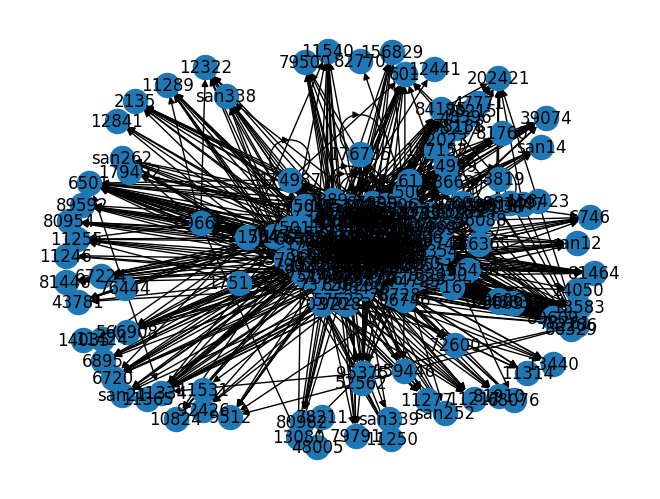

In [ ]:
#using the graph filter only the intertidal links
#filter edges directly from G based on edge attributes
intertidal_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("Intertidal") == True]
#create subgraph
intertidal_G = G.edge_subgraph(intertidal_edges)

#visualize the intertidal graph with better layout and styling
plt.figure(figsize=(15, 10))

# Use spring layout for better positioning
pos = nx.spring_layout(intertidal_G, k=1, iterations=50)

# Draw nodes with different colors based on phylum
phyla = [intertidal_G.nodes[node].get('Phylum', 'Unknown') for node in intertidal_G.nodes()]
unique_phyla = list(set(phyla))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_phyla)))
phylum_colors = dict(zip(unique_phyla, colors))
node_colors = [phylum_colors.get(intertidal_G.nodes[node].get('Phylum', 'Unknown'), 'gray') for node in intertidal_G.nodes()]

# Draw the graph
nx.draw(intertidal_G, pos, 
        node_color=node_colors,
        node_size=50,
        with_labels=False,  # Remove labels for cleaner look
        edge_color='lightgray',
        alpha=0.7,
        arrows=True,
        arrowsize=10)

# Add legend for phyla
legend_elements = [plt.scatter([], [], c=color, s=100, label=phylum) for phylum, color in phylum_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.title(f'Intertidal Food Web Network ({intertidal_G.number_of_nodes()} nodes, {intertidal_G.number_of_edges()} edges)')
plt.tight_layout()
plt.show()
